In [1]:
import numpy as np
import matplotlib.pyplot as plt
import snag
import qse

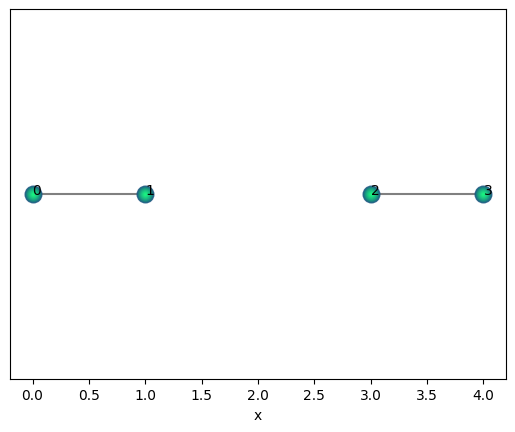

In [23]:
qbits = qse.Qbits(np.array([[0.0], [1.0], [3.0], [4.0]]))
qbits.draw(radius="nearest", show_labels=True)

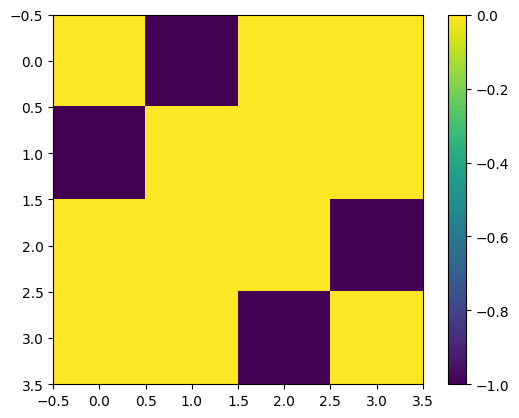

In [9]:
t_mat = -qbits.get_adjacency_matrix(1.0)
plt.imshow(t_mat)
plt.colorbar()
plt.show()

In [82]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=qbits.nqbits)

print(calc.dim)
calc.basis

16


array([[[1, 0, 0, 0],
        [1, 0, 0, 0]],

       [[1, 0, 0, 0],
        [0, 1, 0, 0]],

       [[1, 0, 0, 0],
        [0, 0, 1, 0]],

       [[1, 0, 0, 0],
        [0, 0, 0, 1]],

       [[0, 1, 0, 0],
        [1, 0, 0, 0]],

       [[0, 1, 0, 0],
        [0, 1, 0, 0]],

       [[0, 1, 0, 0],
        [0, 0, 1, 0]],

       [[0, 1, 0, 0],
        [0, 0, 0, 1]],

       [[0, 0, 1, 0],
        [1, 0, 0, 0]],

       [[0, 0, 1, 0],
        [0, 1, 0, 0]],

       [[0, 0, 1, 0],
        [0, 0, 1, 0]],

       [[0, 0, 1, 0],
        [0, 0, 0, 1]],

       [[0, 0, 0, 1],
        [1, 0, 0, 0]],

       [[0, 0, 0, 1],
        [0, 1, 0, 0]],

       [[0, 0, 0, 1],
        [0, 0, 1, 0]],

       [[0, 0, 0, 1],
        [0, 0, 0, 1]]])

In [83]:
same_mol = (
    calc.basis[:, :, :2].sum(2).sum(1) // 2 + calc.basis[:, :, 2:].sum(2).sum(1) // 2
)
same_mol

array([1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

In [97]:
u = 10.0
h_u = u * calc.n_up_n_dn()
print(h_u)
hamiltonian = calc.hopping(t_mat) + np.diag(h_u)

[10.  0.  0.  0.  0. 10.  0.  0.  0.  0. 10.  0.  0.  0.  0. 10.]


In [98]:
result = np.linalg.eigh(hamiltonian)
result.eigenvalues

array([-2.00000000e+00, -2.00000000e+00, -3.85164807e-01, -3.85164807e-01,
       -6.26730616e-16, -1.22404218e-16, -8.92349004e-17, -1.12540420e-34,
        4.21288051e-17,  5.28057074e-17,  2.00000000e+00,  2.00000000e+00,
        1.00000000e+01,  1.00000000e+01,  1.03851648e+01,  1.03851648e+01])

In [99]:
psi = result.eigenvectors[:, 0]
probs = (np.conj(psi) * psi).real
print(probs, probs.sum(), (probs * same_mol).sum())

[0.00000000e+00 1.38666956e-32 2.50000000e-01 2.50000000e-01
 1.38666956e-32 0.00000000e+00 2.50000000e-01 2.50000000e-01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00] 1.0 2.773339119917619e-32
